# EMULATE MY SIMPLE NCL ENSO DIAGNOSTICS BASED ON NINO3.4 TIMESERIES

In [12]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import linregress

import glob as glob
import os as os

import importlib

import enso_utils as mypy

import os
os.cpu_count()

128

In [13]:
from dask.distributed import Client
from ncar_jobqueue import NCARCluster

In [14]:
#cluster.close()
#client.shutdown()

In [15]:
cluster = NCARCluster(project='P93300642',interface='ext',walltime="12:00:00")
cluster
cluster.scale(jobs=8)
client = Client(cluster)
client

/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Future

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/45871/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/45871/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.173:38607,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/45871/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [16]:
print(cluster.job_script())

#!/usr/bin/env bash

#PBS -N dask-worker-casper-dav
#PBS -q casper
#PBS -A P93300042
#PBS -l select=1:ncpus=1:mem=25GB
#PBS -l walltime=12:00:00
#PBS -e /glade/derecho/scratch/rneale/dask/casper-dav/logs/
#PBS -o /glade/derecho/scratch/rneale/dask/casper-dav/logs/

/glade/work/rneale/python/miniconda3/envs/neale_vproc/bin/python3.10 -m distributed.cli.dask_worker tcp://128.117.208.173:38607 --name dummy-name --nthreads 2 --memory-limit 23.28GiB --nanny --death-timeout 60 --local-directory /glade/derecho/scratch/rneale/dask/casper-dav/local-dir --interface ext



/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Future

## Setup Run Information

In [61]:

'' CASE SPECIFICATIONS '''

enso_cases = ['ERA5','CESM2','CESM1','156','162','163','166','170','171']
enso_names = ['ERA5',
              'b.e21.BHISTcmip6.f09_g17.LE2-1001.001',
              'b.e11.B1850C5CN.f09_g16.005',
              'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.156',
              'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.162',
              'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.163',
              'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.166',
              'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.170',
              'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.171'
             ]              

#enso_cases = ['ERA5','156']
#enso_names = ['ERA5',
#              'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.156']

xnino_reg = 'nino3' ; ynino_reg = 'nino3' ; 

enso_ystart = [1979,1860,430,30,30,30,30,30,30]
enso_yend   = [2018,1899,470,70,70,70,70,70,70]

#season = 'DJF' ; get_months = [12,1,2]
#season = 'NDJFM' ; get_months = [11,12,1,2,3]
season = 'ANN' ; get_months = [1,2,3,4,5,6,7,8,9,10,11,12]

lread_in_all_hist = False   # Read in all the CESM/CAM history files in a directory (max out for 100 years)

lwrite_ts_file = True  # Write out a timeseries of 2D SST/VAR variables (if they don't exist)
lread_ts_file = True # Read in a timeseries of 2D SST/VAR variables (if they exist).


ncases = len(enso_cases)

loop_icases = ncases # Number of set cases to run.
is_in_situ = False  # For real, non-reanlysis observations.

## Grab data and averaged

In [62]:
''' VARIABLE SEPCIFICATIONS '''

var_x = 'sst'  ; evar_x = 'sst' ; cvar_x = 'TS' ; sunits = 'K'
#var_comp = 'taux' ; evar_comp = 'chnk' ; ovar_scale = -30.*1.e3 ; cvar_comp = 'TAUX' ; cvar_comp = 'TAUX'; cvar_scale = -1.*1.e3 ;  vunits = 'N/m^2'
var_y = 'prect' ; evar_y = 'tp' ; ovar_scale = 1000. ; cvar_y = 'PRECT' ; cvar_scale = 86400.*1000. ; vunits = 'mm/day' # mon means (m->mm = *1000.)  



[1]  of  [9]  +++ ERA5 +++
-- Reading in data --
     -Requested SST year range =  1979 - 2018
     -Available SST time range =  1978.Jan - 2023.Dec
     -- Calculating nino properties

[2]  of  [9]  +++ b.e21.BHISTcmip6.f09_g17.LE2-1001.001 +++
-- Reading in data --
- Grabbing file(s) for LENS1/2 (CESM1/2)
     -Requested SST year range =  1860 - 1899
     -Available SST time range =  1850.Feb - 1900.Jan
     -- Calculating nino properties

[3]  of  [9]  +++ b.e11.B1850C5CN.f09_g16.005 +++
-- Reading in data --
- Grabbing file(s) for LENS1/2 (CESM1/2)
/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/monthly/PRECT/b.e11.B1850C5CN.f09_g16.005.cam.h0.PRECT.04*.nc
/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/monthly/PRECC/b.e11.B1850C5CN.f09_g16.005.cam.h0.PRECC.04*.nc
     -Requested SST year range =  430 - 470
     -Available SST time range =  0400.Feb - 0500.Jan
     -- Calculating nino properties

[4]  of  [9]  +++ b.e30_alpha06e.

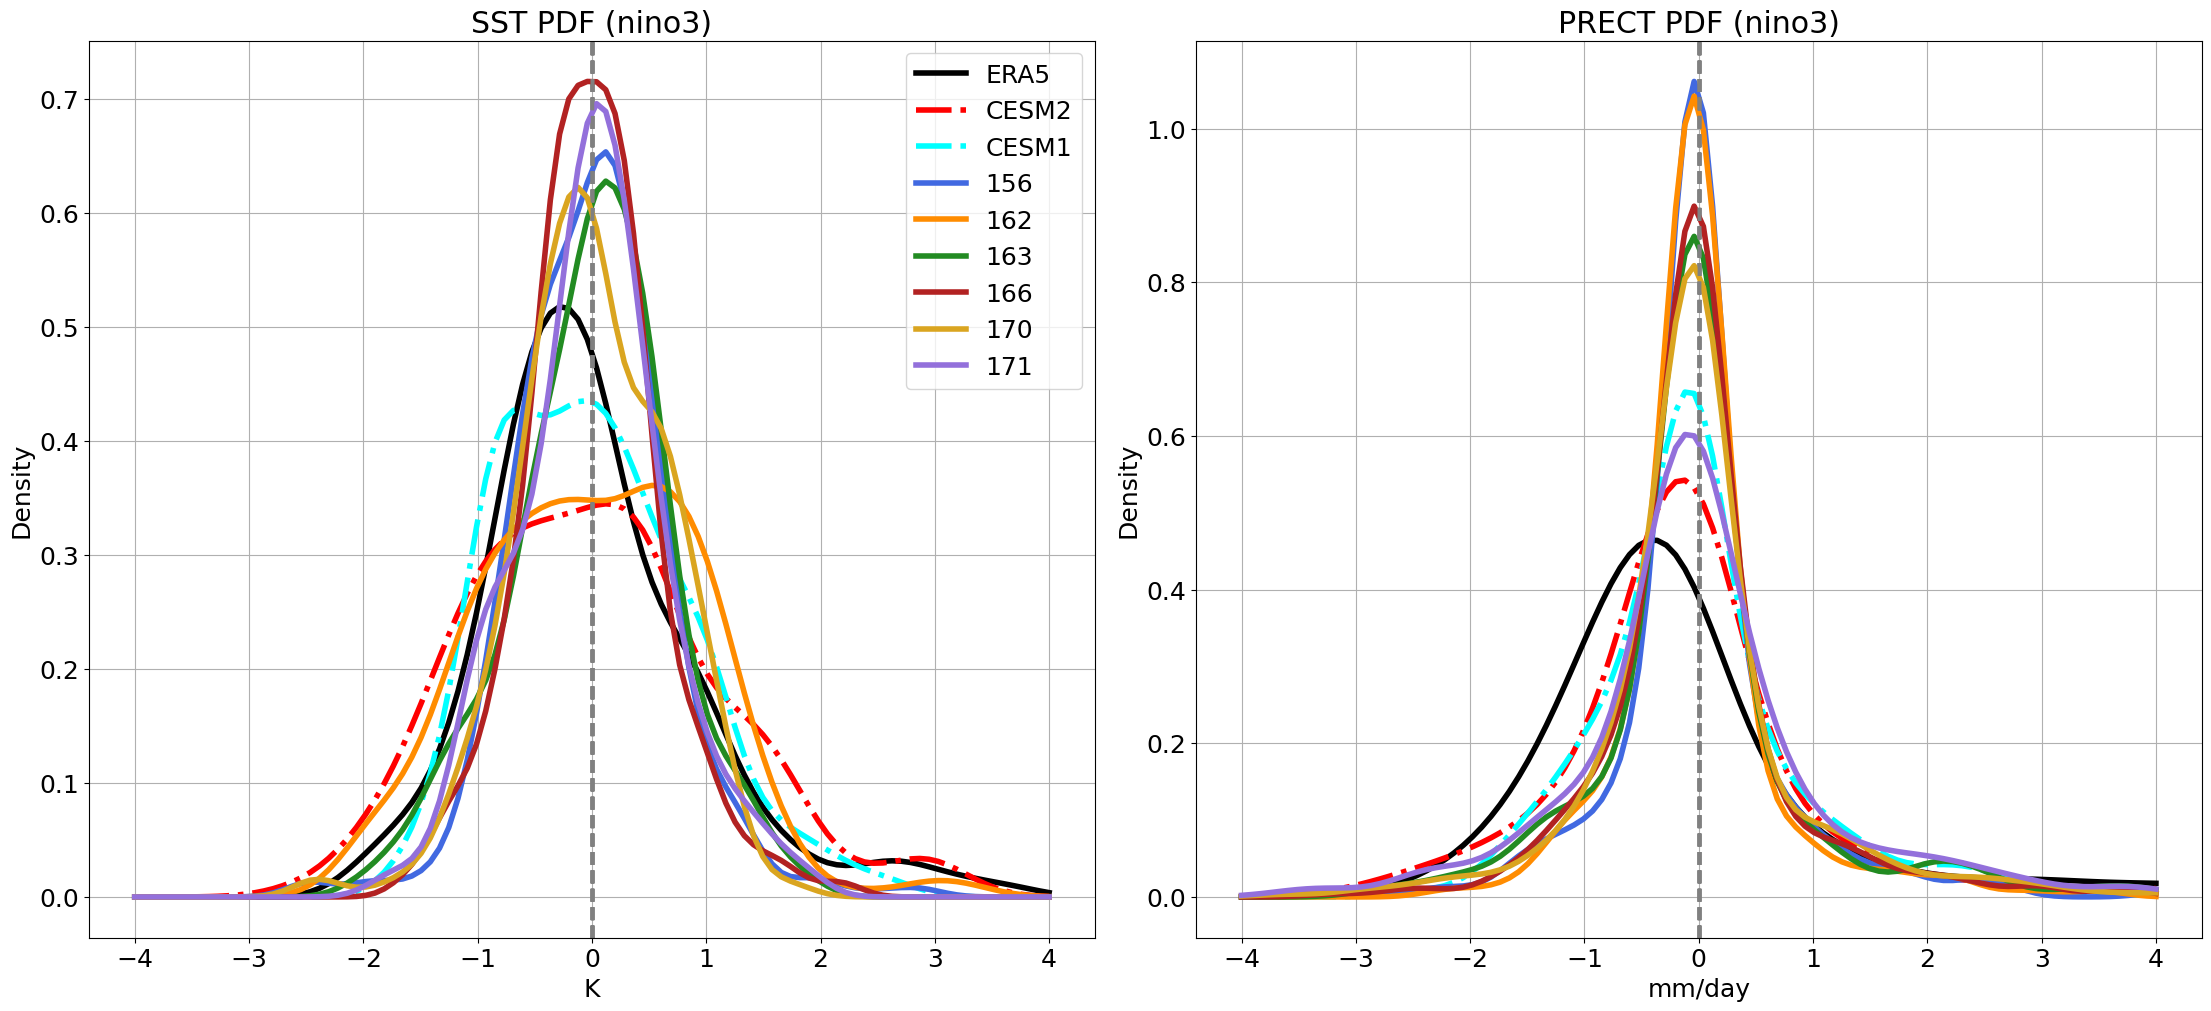

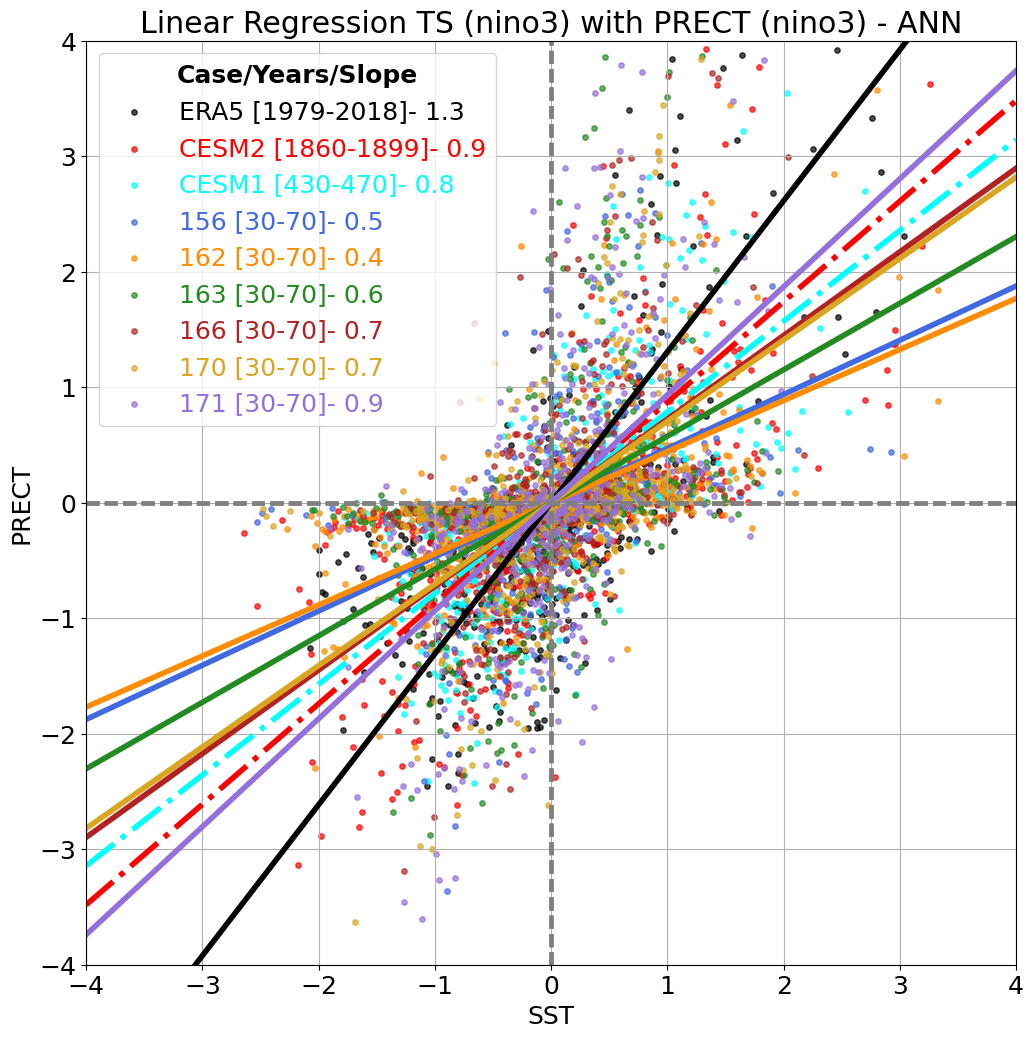

In [63]:
dir_ncout = '/glade/work/rneale/python-netcdf/enso/'

dir_data = '/glade/work/rneale/data/'
dir_fig = '/glade/u/home/rneale/python/python-figs/enso/'



### Settings

figp, axp = plt.subplots(
    nrows=1,
    ncols=2,
    constrained_layout=True,
    figsize=(22, 10),
    )

figs, axs = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(12, 12),
    )


plt.rcdefaults()
plt.rcParams.update({'font.size': 18})



# nino and var regions
## Taking settings from the Clivar 2020 ENSO metrics


xnino_w,xnino_e,xnino_n,xnino_s = mypy.nino_region(xnino_reg)
ynino_w,ynino_e,ynino_n,ynino_s = mypy.nino_region(ynino_reg)


# Plot ranges

# SST
smin,smax = -4.,4

#Variable vmin
if cvar_comp == 'PRECT' :  vmin,vmax = -4.,4.
if cvar_comp == 'TAUX' :  vmin,vmax = -70,70.


### Looping cases/runs

sst_xvals = np.linspace(smin, smax, 100)
var_xvals = np.linspace(vmin, vmax, 100)

#scat_cols = ['black','blue','red','purple','orange','green','cyan']

scat_cols = [
    "black",
    "red",
    "cyan",
    "royalblue",
    "darkorange",
    "forestgreen",
    "firebrick",
    "goldenrod",
    "mediumpurple",
    "deepskyblue",
    "crimson"
    
]




''''''
''' LOOP OVER CASES '''
''''''

for icase,case in enumerate(enso_cases[0:loop_icases]):


    lstyle = '--' if icase==0  else '-'
    lstyle = '-.' if icase in [1,2]  else '-'
    
    lmark = '^' if icase==0 else ''
        
    
    cname = enso_names[icase]
    yr0 = enso_ystart[icase] ; pyr0 = f"{yr0:04d}"
    yr1 = enso_yend[icase] ; pyr1 = f"{yr1:04d}"



    
    print('')
    print([icase+1],' of ',[ncases],' +++ '+ enso_names[icase] + ' +++')
    print('-- Reading in data --')


    # Does a timeseries dataset exist for this case

    ofile_sst = dir_ncout+cname+'_'+cvar_sst+'_mmeans_ts.nc'
    ofile_var = dir_ncout+cname+'_'+cvar_comp+'_mmeans_ts.nc'
    
    # Case 'type'

    if cname in ['ERA5']: ctype = 'obs'
    if 'b.e3' in cname : ctype = 'cesm3'
    if 'b.e2' in cname : ctype = 'cesm2'
    if 'b.e1' in cname : ctype = 'cesm1'

    
    # Obs (ERA5 for now)

    match case:
    
        da_x, da_y = mypy.get_dataset(case,var_x, var_y)
    
        case 'ERA5':
        
            da_x = xr.open_dataset(dir_era5+var_x+'_era5_monthly_1x1.nc')[evar_x]
            
            if is_in_situ:
                da_y = xr.open_dataset(dir_data+'tropflux/taux_tropflux_1m_1979-2018.nc')['taux']    
                da_y = da_var.rename({'latitude': 'lat', 'longitude': 'lon'})
                vscale = 1.e3
            else:
                da_y = xr.open_dataset(dir_era5+var_y+'_era5_monthly_1x1.nc')[evar_y]  
                vscale = ovar_scale
            
            if 'valid_time' in da_y.dims:
                da_y = da_y.rename({'valid_time': 'time'})
    
            


        case _ if ctype in ['cesm1','cesm2']:
            
            if ctype == 'cesm1':
                dir_lens = '/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/monthly/'
                files_hist_x = dir_lens+cvar_x+'/'+cname+'.cam.h0.'+cvar_x+'.04*.nc'
                files_hist_y = dir_lens+cvar_y+'/'+cname+'.cam.h0.'+cvar_y+'.04*.nc'
                files_ls_x  = glob.glob(files_hist_x)
                files_ls_y  = glob.glob(files_hist_y)
                
                
            else:
                
                dir_lens = '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/atm/proc/tseries/month_1/'
                files_hist_x = dir_lens+cvar_x+'/'+cname+'.cam.h0.'+cvar_x+'.18*.nc'
                files_hist_y = dir_lens+cvar_y+'/'+cname+'.cam.h0.'+cvar_y+'.18*.nc'
                files_ls_x  = glob.glob(files_hist_x)
                files_ls_y  = glob.glob(files_hist_y)
                
         
            
            print('- Grabbing file(s) for LENS1/2 (CESM1/2)')
           
            da_sst = xr.open_mfdataset(files_ls_x,parallel=True, combine="by_coords",data_vars="minimal", coords="minimal")[cvar_x]
            
            if ctype=='cesm1' and cvar_comp == 'PRECT': # Need to grab PRECC and PRECL files separately 

                files_hist_pc = files_hist_y.replace('PRECT', 'PRECC')
                files_hist_pl = files_hist_y.replace('PRECT', 'PRECL')

                files_ls_pc  = glob.glob(files_hist_pc)
                files_ls_pl  = glob.glob(files_hist_pl)
                
                da_pc = xr.open_mfdataset(files_ls_pc,parallel=True, combine="by_coords",data_vars="minimal", coords="minimal")['PRECC']
                da_pl = xr.open_mfdataset(files_ls_pl,parallel=True, combine="by_coords",data_vars="minimal", coords="minimal")['PRECL']
                
                da_y = da_pc+da_pl
                
            else:
                da_y = xr.open_mfdataset(files_ls_y,parallel=True, combine="by_coords",data_vars="minimal", coords="minimal")[cvar_y]
              
                
        
            vscale = cvar_scale
    
        case _ if ctype in 'cesm3':
    
    
            # add vscale here
            vscale = cvar_scale
            
            if os.path.exists(ofile_x) and os.path.exists(ofile_y) and lread_ts_file:
    
                print('- Existing files exist for the case - using them')
            
                print('     ',ofile_x)
                print('     ',ofile_y)
            
                da_x = xr.open_dataset(ofile_x)[cvar_x]
                da_y = xr.open_dataset(ofile_y)[cvar_y]
                
                # Pick the right directory (hannay/gmarques)
    
                dir_c3 = '/glade/derecho/scratch/hannay/archive/'
                
                if os.path.isdir(dir_c3+cname):
                    print("   - Cecile's Run")
                # Your operation here, e.g. read/write files
                else:
                    print("   - Gustavo's Run")
                    dir_c3 = '/glade/derecho/scratch/gmarques/archive/'
    
                
    # Grab files and read in.
    
                # Trim down range of files to read in requested years, otherwise read in all.
    
                
                if not lread_in_all_hist:
                    files_hist = []
                    yrange = list(range(yr0, yr1+1))
    #                yr_arr_string = "[" + ",".join(f"{n:04d}" for n in yrange) + "]"
                    yr_arr_strings = [f"{num:04d}" for num in yrange]
    
    #                print(y_arr_strings)
                    for yr_str in yr_arr_strings:
    #                    print(yr_str)
                        file_ls = dir_c3+cname+'/atm/hist/'+cname+'.cam.h0a.'+yr_str+'*.nc'
                        files_hist.extend(glob.glob(file_ls)) 
    
                    files_hist.sort()
                
            else:
                file_hist = dir_c3+cname+'/atm/hist/'+cname+'.cam.h0a.*.nc'
                    
               
     
     # File checks           
                
                print('-Reading ',len(files_hist),' files  (first/last)')
                print('   -',files_hist[0])
                print('   -',files_hist[-1])
                
            # Open them as multiple files
    
                print('- Slow read of h0a output...')
                ds_cesm = xr.open_mfdataset(files_hist,parallel=True, combine="by_coords",data_vars="minimal", coords="minimal")
                
                da_x = ds_cesm[cvar_x]
                da_y = ds_cesm[cvar_y]
    
                print('-Done')
                
            # Write out the timeseries of 2D field files?
            
                if lwrite_ts_file: 
    
                    print("- Write out files of 2D fields SST/VAR")
        
                    print('    ',ofile_x)
                    print('    ',ofile_y)
        
        
                    da_x.to_netcdf(ofile_x,mode="w")
                    da_y.to_netcdf(ofile_y,mode="w")
        
                    da_x.close()
                    da_y.close()
    
                    print('-Done')

        case _:
            
            print("No ctype match for "+case)
    
    # Time info

    fyr0 = da_sst.time.min().dt.strftime('%Y.%b').item()
    fyr1 = da_sst.time.max().dt.strftime('%Y.%b').item()
        
    print('     -Requested SST year range = ',yr0,'-',yr1)
    print('     -Available SST time range = ',fyr0,'-',fyr1)

    if (da_sst.time.min().values != da_var.time.min().values
        and da_sst.time.max().values != da_var.time.max().values):
        print('File(s) time range of SST does not match that of ',cvar_comp)


# Subset time range (years, seasons) from available full range. Used padded 4 digit integers.


    tsst_mask = ((da_sst.time.dt.year >= yr0) & (da_sst.time.dt.year <= yr1) &
                    (da_sst.time.dt.month.isin(get_months)))
    da_sst = da_sst.sel(time=tsst_mask)

    
    tvar_mask = ((da_var.time.dt.year >= yr0) & (da_var.time.dt.year <= yr1) &
                    (da_var.time.dt.month.isin(get_months)))

    da_var = da_var.sel(time=tvar_mask)*vscale
    

     
    # Calculate nino3.4 and VAR timeseries.

    print('     -- Calculating nino properties')
    
    nino34_sst = da_sst.sel(lat=slice(snino_s, snino_n), lon=slice(snino_w, snino_e))
    nino34_var = da_var.sel(lat=slice(vnino_s, vnino_n), lon=slice(vnino_w, vnino_e))
    
    # Step 3: Area-weighted average over lat/lon
    weights = np.cos(np.deg2rad(nino34_sst.lat))
    
    nino34_wsst = nino34_sst.weighted(weights).mean(dim=["lat", "lon"])
    nino34_wvar = nino34_var.weighted(weights).mean(dim=["lat", "lon"])
    
    # Step 4: Remove the mean annual cycle
    
    # Group by month, calculate climatology (mean for each calendar month)
    nino34_csst = nino34_wsst.groupby('time.month').mean('time')
    nino34_cvar = nino34_wvar.groupby('time.month').mean('time')
    
    # Subtract monthly climatology to get anomalies
    nino34_asst = nino34_wsst.groupby('time.month') - nino34_csst
    nino34_avar = nino34_wvar.groupby('time.month') - nino34_cvar
    
    # Convert to NumPy and flatten, mask NaNs
    
    sst_1d = nino34_asst.values.flatten()
    var_1d = nino34_avar.values.flatten()
    
    sst_1d = sst_1d[~np.isnan(sst_1d)] 
    var_1d = var_1d[~np.isnan(var_1d)]

    # Strip out requested season before constructing PDFs

    ''' PDFs of monthly SST and Var '''

    sst_kde = gaussian_kde(sst_1d)
    sst_pdf = sst_kde(sst_xvals)

    var_kde = gaussian_kde(var_1d)
    var_pdf = var_kde(var_xvals)

    axp[0].plot(sst_xvals, sst_pdf, label=case,linewidth=4,color=scat_cols[icase],linestyle=lstyle)
    axp[1].plot(var_xvals, var_pdf, linewidth=4, color=scat_cols[icase],linestyle=lstyle)


    
    ''' Scatter plot of the relationship between SST and VAR '''    
    
    # Linear regression

    slope_neg, intercept_neg, r_value_neg, p_value_neg, std_err_neg = linregress(sst_1d[sst_1d < 0], var_1d[sst_1d < 0])
    slope_pos, intercept_pos, r_value_pos, p_value_pos, std_err_pos = linregress(sst_1d[sst_1d > 0], var_1d[sst_1d > 0])
    slope, intercept, r_value, p_value, std_err = linregress(sst_1d, var_1d)
    
    sst_even_neg = np.linspace(smin, 0, 50) 
    line_neg = slope_neg * sst_even_neg + intercept_neg

    sst_even_pos = np.linspace(0, smax, 50) 
    line_pos = slope_pos * sst_even_pos + intercept_pos

    sst_even = np.linspace(smin, smax, 100) 
    line = slope * sst_even + intercept
    
    # Scatter plot

    case_yrs = case+' ['+str(int(yr0))+'-'+str(int(yr1))+']- '+f"{slope:.1f}"
    axs.scatter(sst_1d, var_1d, label=case_yrs, alpha=0.7, color=scat_cols[icase],s=15)

    axs.plot(sst_even, line, color=scat_cols[icase],linewidth=4,linestyle=lstyle)
#    axs.plot(sst_even_pos, line_pos, color=scat_cols[icase],linewidth=4,linestyle=lstyle)

    
    axs.set_xlabel("SST") ; axs.set_xlim([smin,smax])
    axs.set_ylabel(cvar_comp) ; axs.set_ylim([vmin,vmax])
    axs.set_title('Linear Regression '+cvar_sst+' ('+snino_reg+') with '+cvar_comp+' ('+vnino_reg+') - '+season)

    if icase==ncases-1:
        legend = axs.legend(title='Case/Years/Slope')
        legend_labels = legend.get_texts()
        legend.get_title().set_fontweight('bold') 
        for ileg, leg_lab in enumerate(legend_labels): leg_lab.set_color(scat_cols[ileg])   # Dataset 1
        
    axs.grid(True)
    axs.axhline(0, color='gray', linestyle='--', linewidth=2.5)
    axs.axvline(0, color='gray', linestyle='--', linewidth=2.5)

         
    del(da_sst)
    del(da_var)




    
    # Set the PDF plots
    
    axp[0].set_title('SST PDF ('+snino_reg+')') ; axp[1].set_title(cvar_comp+' PDF ('+vnino_reg+')') 
    axp[0].set_xlabel(sunits) ; axp[1].set_xlabel(vunits) 
    axp[0].set_ylabel('Density') ; axp[1].set_ylabel('Density')
    axp[0].grid(True) ; axp[1].grid(True) 
    axp[0].axvline(x=0., color='gray',linestyle='--', linewidth=2.5) ; axp[1].axvline(x=0., color='gray',linestyle='--', linewidth=2.5)
    axp[0].legend() 




# OUTPUT

figs.show()
figs.savefig(dir_fig+'SST_'+cvar_comp+'_'+season+'_'+snino_reg+'_scatter_cesm3_monthly.png')

